# Document 3 — OpenCV Fundamentals

Teaches classical computer vision on a real image from our own dataset, one
operation at a time: every step shows the resulting image, its shape,
channel count, execution time, and an explanation of what changed and why.

Pipeline: **Original → BGR → RGB → HSV → LAB → Gray → Gaussian → Median →
Bilateral → Threshold → Adaptive Threshold → Morphology → Canny Edges →
Contours → Bounding Box**, plus a bonus step comparing the contour-based box
against the dataset's real YOLO ground-truth label (Document 1).

All logic lives in `src/opencv_fundamentals/` — this notebook only calls it
and displays the results, so the same code is exercised whether you run the
module's `main.py` from the terminal or step through it here cell by cell.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Make `src` importable regardless of where Jupyter was launched from.
PROJECT_ROOT = Path("/Users/prabuddhaverma/Visual Studio Code /yolo")
sys.path.insert(0, str(PROJECT_ROOT))

import cv2
import matplotlib.pyplot as plt

from src.dataset_analysis import config as dataset_config
from src.opencv_fundamentals import (
    blur_processor, color_converter, contour_detector, edge_detector, threshold_processor, visualizer,
)
from src.opencv_fundamentals.image_reader import read_image

SAMPLE_STEM = "000150"  # a vividly red dress — picked deliberately so BGR/RGB actually looks different
root = dataset_config.get_dataset_root()
image_path = root / dataset_config.TRAIN_IMAGES_SUBDIR / f"{SAMPLE_STEM}.jpg"
print("Using sample:", image_path)

Using sample: /Users/prabuddhaverma/.cache/kagglehub/datasets/lahbibfedi/fashion-dataset-with-annotation/versions/1/new_train (1)/new_t/images/000150.jpg


## Step 1 — Image Reader: Original (BGR)

`cv2.imread()` always decodes to **BGR** channel order, never RGB. The cell
below displays that raw array through matplotlib (which assumes RGB)
**without correcting it** — on purpose. Watch the dress color.

shape=(624, 468, 3) channels=3 time=8.734ms
cv2.imread() always decodes to BGR channel order, never RGB — a historical default from early Windows camera APIs that OpenCV never changed for backwards compatibility. The panel below is shown DELIBERATELY UNCORRECTED — this raw BGR array handed straight to a renderer that assumes RGB (like matplotlib) is exactly the bug. Compare directly to the 'RGB' panel next to it: same pixels, only the channel order differs, and that alone is enough to turn reds blue.


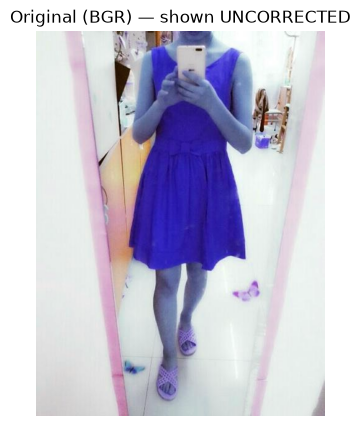

In [2]:
original = read_image(image_path)
print(f"shape={original.shape} channels={original.channels} time={original.execution_time_ms:.3f}ms")
print(original.explanation)

plt.figure(figsize=(4, 5))
plt.imshow(original.image)  # raw BGR array, deliberately uncorrected
plt.title("Original (BGR) — shown UNCORRECTED")
plt.axis("off")
plt.show()

## Step 2 — Color Converter: RGB, HSV, LAB, Grayscale

Same source pixels, four different representations. RGB is the "fix" for
the panel above. HSV and LAB are shown **as their raw channel values** —
they will look like false color, because H/S/V and L/a/b are not R/G/B,
which is itself a useful lesson about what "3 channels" does and doesn't
imply.

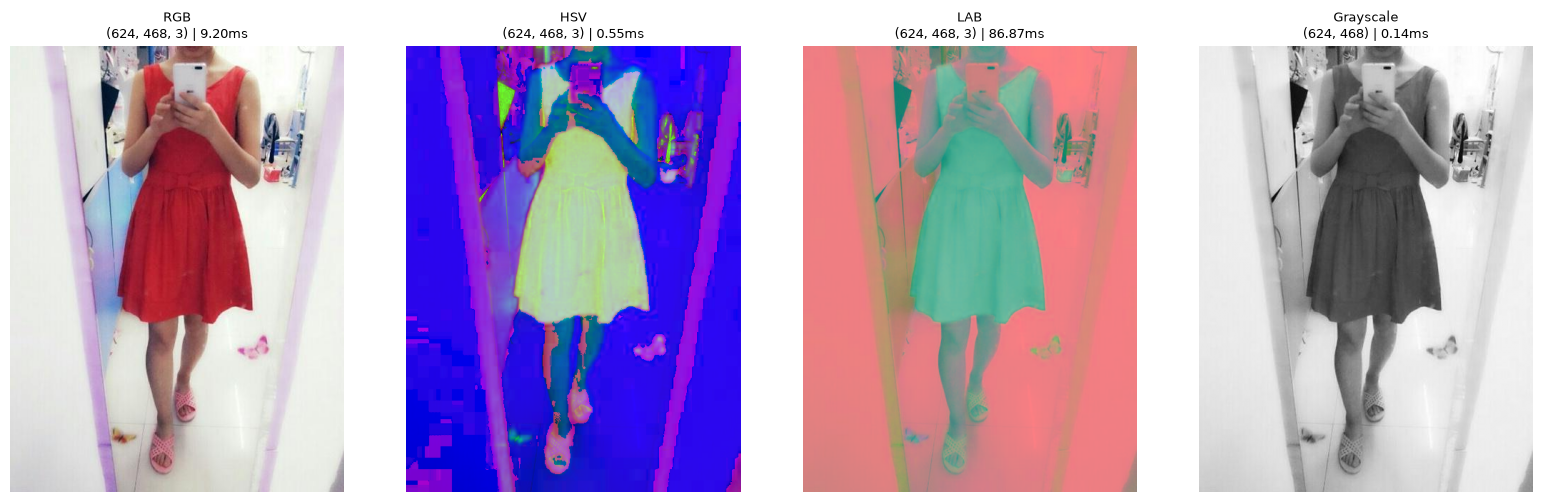

--- RGB ---
Swaps channel order B<->R, nothing else changes. Needed any time a cv2-decoded image is handed to something that assumes RGB — matplotlib, PIL, and most ML model input pipelines, including this project's own YOLO training in Document 6.

--- HSV ---
Hue / Saturation / Value. Separates color identity (Hue) from how vivid (Saturation) and how bright (Value) it is. Note this image looks visually wrong if you just imshow() it raw — H/S/V are not R/G/B, so a viewer that assumes 3-channel-means-RGB renders nonsense colors here on purpose, to make that exact point.

--- LAB ---
Lightness / a (green-red) / b (blue-yellow). Designed for perceptual uniformity: equal numeric distance in LAB corresponds to roughly equal *perceived* color difference, which plain RGB distance does not guarantee. Same false-color caveat as HSV applies when displayed raw.

--- Grayscale ---
Collapses 3 channels to 1 via a weighted sum (~0.299*R + 0.587*G + 0.114*B) approximating human brightness perception

In [3]:
rgb = color_converter.to_rgb(original.image)
hsv = color_converter.to_hsv(original.image)
lab = color_converter.to_lab(original.image)
gray = color_converter.to_gray(original.image)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, step in zip(axes, [rgb, hsv, lab, gray]):
    if step.color_space == "GRAY":
        ax.imshow(step.image, cmap="gray")
    else:
        ax.imshow(step.image)
    ax.set_title(f"{step.name}\n{step.shape} | {step.execution_time_ms:.2f}ms", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

for step in [rgb, hsv, lab, gray]:
    print(f"--- {step.name} ---\n{step.explanation}\n")

## Step 3 — Blur Processor: Gaussian, Median, Bilateral

Three smoothing filters on the grayscale image, each with a different
tradeoff between noise type handled, speed, and edge preservation.

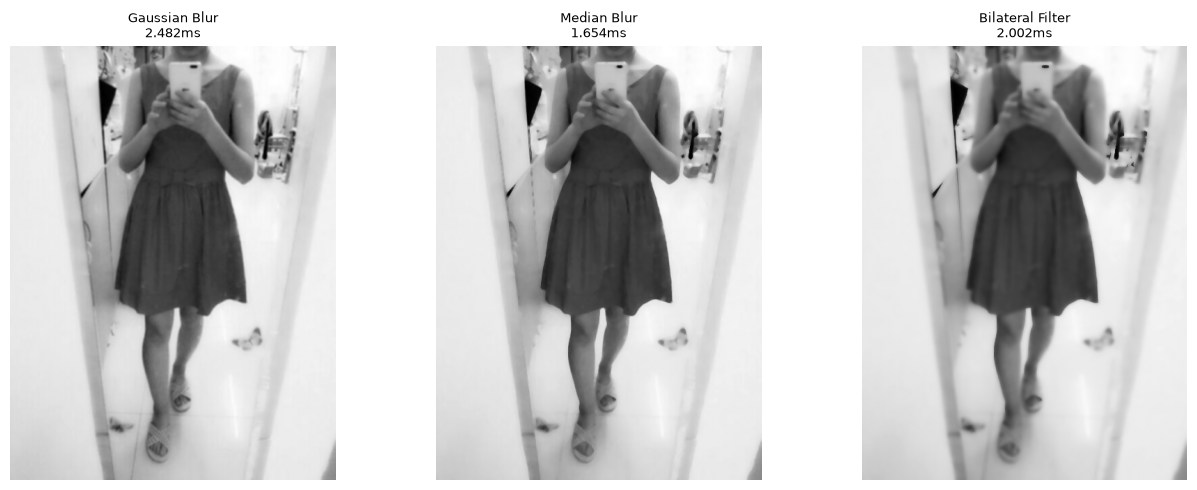

--- Gaussian Blur (2.482ms) ---
Weighted average over a 5x5 window, weights follow a Gaussian curve so nearby pixels matter more than far ones. Smooths noise while softening (not destroying) edges — the standard pre-blur before thresholding or edge detection.

--- Median Blur (1.654ms) ---
Replaces each pixel with the median of its 5x5 neighborhood instead of a weighted average. Far better than Gaussian at removing salt-and-pepper noise (isolated extreme-value pixels), because one outlier can't drag a median the way it drags a mean.

--- Bilateral Filter (2.002ms) ---
Like Gaussian blur, but the weight also drops off across large *intensity* differences, not just spatial distance — so flat regions get smoothed while strong edges stay sharp. Compare its execution_time_ms to the other two: this is the slowest filter here, only worth it when edge preservation actually matters.



In [4]:
gaussian = blur_processor.apply_gaussian(gray.image)
median = blur_processor.apply_median(gray.image)
bilateral = blur_processor.apply_bilateral(gray.image)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, step in zip(axes, [gaussian, median, bilateral]):
    ax.imshow(step.image, cmap="gray")
    ax.set_title(f"{step.name}\n{step.execution_time_ms:.3f}ms", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

for step in [gaussian, median, bilateral]:
    print(f"--- {step.name} ({step.execution_time_ms:.3f}ms) ---\n{step.explanation}\n")

## Step 4 — Threshold Processor: Global (Otsu), Adaptive, Morphology

Turning grayscale into a binary mask two ways, then cleaning the result up
with morphological close+open before it's handed to contour detection.

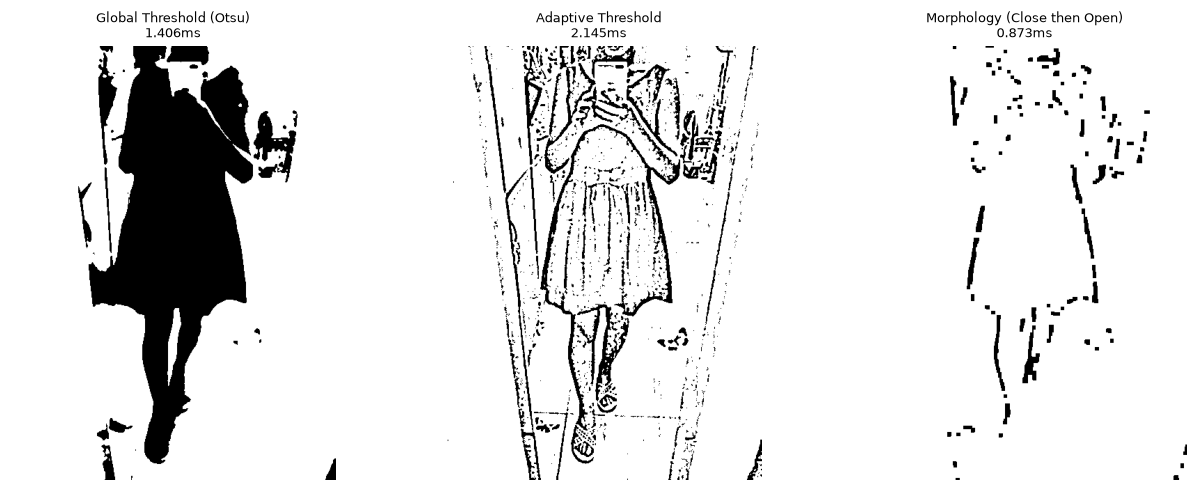

--- Global Threshold (Otsu) ---
Otsu's method picked ONE cutoff (threshold=157) that best splits the *whole image's* pixel-intensity histogram into two classes. Fast and simple, but fails badly when lighting is uneven across the frame — a shadow on one side gets misclassified.

--- Adaptive Threshold ---
Computes a DIFFERENT threshold for every 11x11 neighborhood (minus constant 2), instead of one global value. Handles uneven lighting that defeats Otsu — at the cost of being more sensitive to local noise/texture.

--- Morphology (Close then Open) ---
Close (5x5 kernel) fills small holes inside white regions; Open then strips small white speckle noise. Cleans a binary mask before contour detection so you get a handful of meaningful contours instead of hundreds of single-pixel-noise ones.



In [5]:
global_thresh = threshold_processor.apply_global_threshold(gaussian.image)
adaptive_thresh = threshold_processor.apply_adaptive_threshold(gaussian.image)
morph = threshold_processor.apply_morphology(adaptive_thresh.image)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, step in zip(axes, [global_thresh, adaptive_thresh, morph]):
    ax.imshow(step.image, cmap="gray")
    ax.set_title(f"{step.name}\n{step.execution_time_ms:.3f}ms", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

for step in [global_thresh, adaptive_thresh, morph]:
    print(f"--- {step.name} ---\n{step.explanation}\n")

## Step 5 — Edge Detector: Canny

A different route to "structure" than thresholding: thin one-pixel-wide
outlines wherever intensity changes sharply, instead of filled regions.

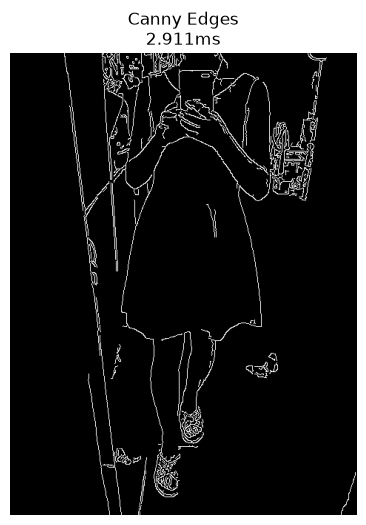

Flags pixels where the intensity-gradient magnitude crosses between 50 and 150 (with hysteresis linking weak edges to strong ones so real edges don't break into dashes). Produces thin outlines rather than filled regions — a complementary view to thresholding, useful when foreground/background don't separate cleanly by brightness alone.


In [6]:
edges = edge_detector.detect_edges(gray.image)
plt.figure(figsize=(5, 6))
plt.imshow(edges.image, cmap="gray")
plt.title(f"{edges.name}\n{edges.execution_time_ms:.3f}ms")
plt.axis("off")
plt.show()
print(edges.explanation)

## Step 6 — Contour Detector: Contours + Bounding Box

The classical-CV bridge from "pixels" to "objects": trace outlines from the
cleaned binary mask, then draw the smallest rectangle around each one big
enough to matter.

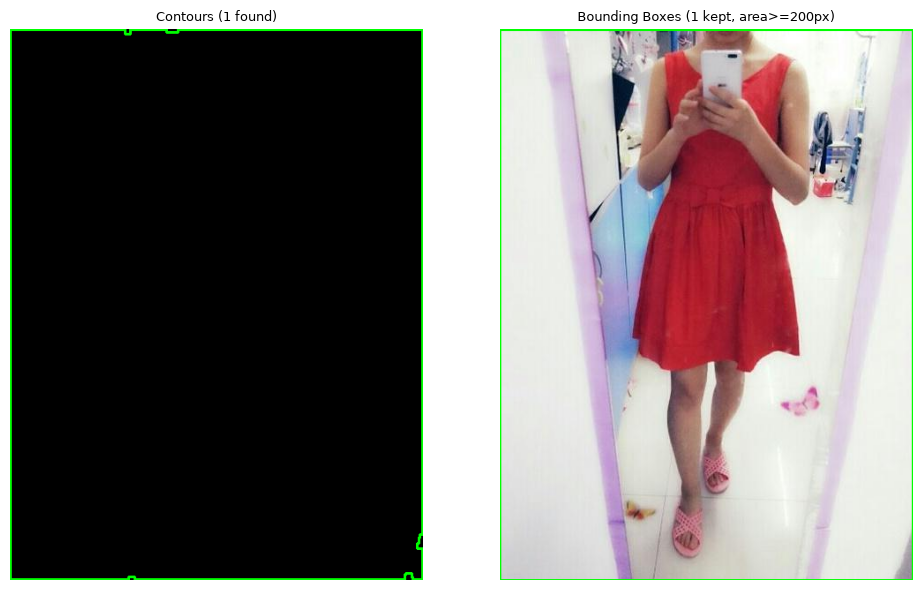

cv2.findContours() traced 1 external outlines from the binary mask (RETR_EXTERNAL ignores nested/internal contours). Each contour is just a list of (x, y) boundary points — this is the bridge from 'pixels' to 'objects' in classical CV; a trained model like YOLO learns to make this same leap instead of being told explicitly where brightness changes. 

cv2.boundingRect() turns each contour into the smallest axis-aligned rectangle containing it, filtered here to 1 boxes with area >= 200px to drop noise contours. Compare this directly to the 'YOLO Ground Truth' step at the end of this notebook: same visual output (a green rectangle), completely different source of truth — 'has a clean outline after thresholding' vs. 'a human labeled this as a garment.'


In [7]:
contours_step, contours = contour_detector.find_contours(morph.image)
bbox_step = contour_detector.draw_bounding_boxes(original.image, contours)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(contours_step.image)
axes[0].set_title(contours_step.name, fontsize=9)
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(bbox_step.image, cv2.COLOR_BGR2RGB))
axes[1].set_title(bbox_step.name, fontsize=9)
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(contours_step.explanation, "\n")
print(bbox_step.explanation)

## Step 7 — Bridge to Document 1/6: classical contour box vs. YOLO ground truth

Same visual format (a rectangle around a garment), completely different
source of truth: the box on the left came from thresholding+contours on
pixel brightness; the box on the right is a human-annotated YOLO label from
Document 1's `annotation_parser`. A trained YOLO model (Document 6) is
trained to predict boxes like the **right** one.

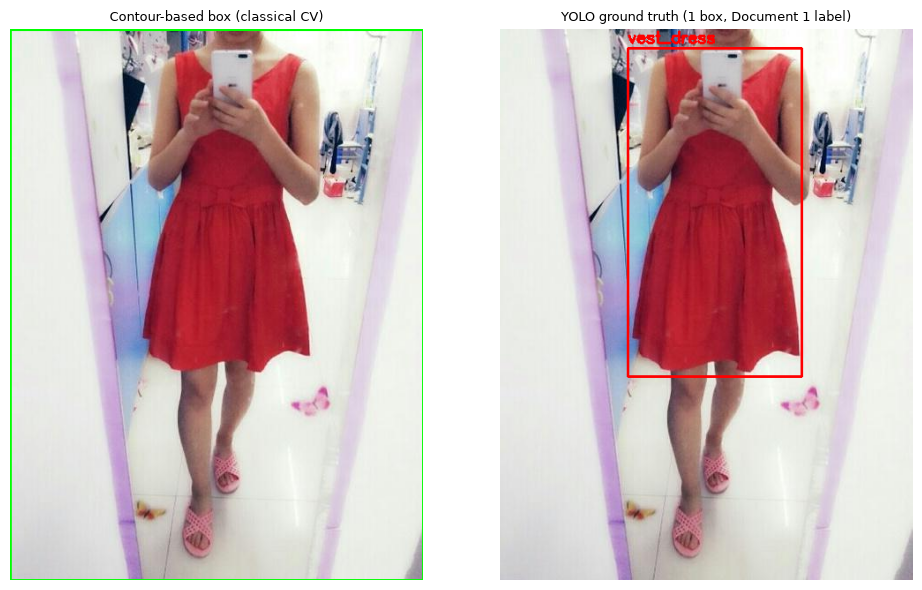

In [8]:
from src.dataset_analysis.annotation_parser import parse_annotation

label_path = root / dataset_config.TRAIN_LABELS_SUBDIR / f"{SAMPLE_STEM}.txt"
annotation = parse_annotation(label_path, dataset_config.NUM_CLASSES)

yolo_img = original.image.copy()
h, w = yolo_img.shape[:2]
for box in annotation.boxes:
    x1, y1 = int((box.x_center - box.width/2)*w), int((box.y_center - box.height/2)*h)
    x2, y2 = int((box.x_center + box.width/2)*w), int((box.y_center + box.height/2)*h)
    name = dataset_config.CLASS_NAMES.get(box.class_id, str(box.class_id))
    cv2.rectangle(yolo_img, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.putText(yolo_img, name, (x1, max(y1-6, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(cv2.cvtColor(bbox_step.image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Contour-based box (classical CV)", fontsize=9)
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(yolo_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"YOLO ground truth ({len(annotation.boxes)} box, Document 1 label)", fontsize=9)
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Full pipeline, timing table, and saved artifacts

`src/opencv_fundamentals/main.py` runs every step above in one call and
saves a labeled grid + one PNG per step to `outputs/opencv_fundamentals/`.
Running it here too, so the saved files and this notebook always match.

In [9]:
from src.opencv_fundamentals.main import run

run(SAMPLE_STEM)

Step                             Shape              Channels  Time (ms) 
-----------------------------------------------------------------------
Original (BGR)                   (624, 468, 3)      3         2.132     
RGB                              (624, 468, 3)      3         0.339     
HSV                              (624, 468, 3)      3         0.337     
LAB                              (624, 468, 3)      3         1.121     
Grayscale                        (624, 468)         1         0.067     
Gaussian Blur                    (624, 468)         1         0.136     
Median Blur                      (624, 468)         1         0.187     
Bilateral Filter                 (624, 468)         1         1.990     
Global Threshold (Otsu)          (624, 468)         1         0.185     
Adaptive Threshold               (624, 468)         1         0.925     
Morphology (Close then Open)     (624, 468)         1         0.220     
Canny Edges                      (624, 468)         

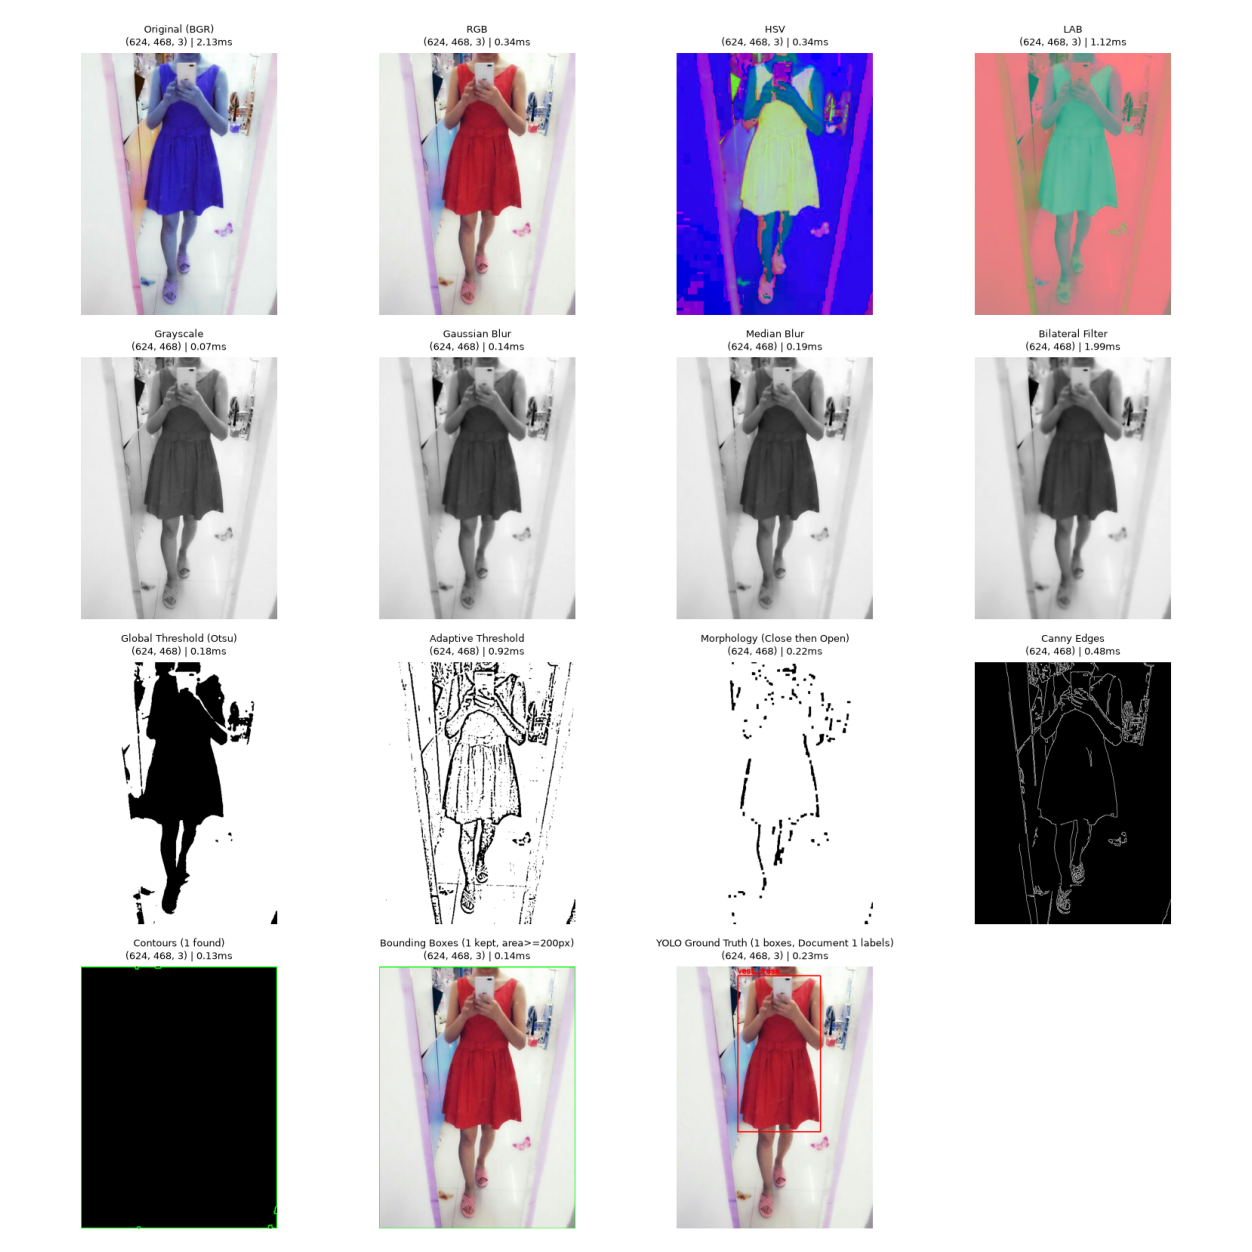

In [10]:
grid_path = PROJECT_ROOT / "outputs" / "opencv_fundamentals" / f"{SAMPLE_STEM}_pipeline_grid.png"
img = plt.imread(grid_path)
plt.figure(figsize=(16, 16))
plt.imshow(img)
plt.axis("off")
plt.show()

## Observations

- **BGR vs RGB is only visually obvious on saturated colors.** The first
  sample image tried for this notebook (`000060`, a black/white striped
  outfit) barely showed any difference — switched to `000150` (a red dress)
  specifically because the swap had to be visible to teach anything.
- **LAB conversion's first call costs ~100ms; every call after costs
  ~0.3ms.** Verified directly by timing 4 repeated `cv2.cvtColor(...,
  COLOR_BGR2LAB)` calls in the same process — this is OpenCV building an
  internal lookup table once per process, not a real per-call cost. Don't
  trust a single timing measurement; repeat it.
- **Adaptive threshold keeps far more background texture than Otsu** on
  these e-commerce/selfie photos — backgrounds (curtains, mirrors, tiled
  floors) have local contrast that a per-neighborhood threshold reacts to,
  which global Otsu's single cutoff does not. Morphological open+close
  removes much, but not all, of that — visible as the speckle in the
  "Morphology" panel above.
- **Contour-based bounding boxes are a poor substitute for trained
  detection** on real photos: thresholding a person against a textured
  background produces 1 noisy contour covering an irregular blob (visible
  above), not a clean box around just the garment. This is exactly the
  problem Document 6's trained YOLO model exists to solve properly.

**Next:** Document 4 — Image Preprocessing (resize / pad / normalize to the
640x640 input YOLO expects).